# Workshop: Why branch analysis is needed for a MIST study in a transmon–resonator system

This notebook develops a concrete example showing why branch analysis is needed for a Measurement-Induced State Transition / Measurement-Induced Transmon Ionization (MIST) study in a transmon–resonator system.

The key point is that without branch analysis, one cannot reliably identify which dressed eigenstate corresponds to the ground-state photon ladder, and therefore one cannot reliably detect the resonances that lead to measurement-induced ionization.

We will follow this logic:

1. The physical situation in MIST
2. What we want to know for MIST
3. What actually happens
4. What the spectrum looks like
5. The problem without branch analysis
6. What branch analysis does
7. Why this is essential for MIST
8. What the MIST diagnostic plot looks like
9. Summary

In [37]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

## 1. The physical situation in MIST

Consider a transmon coupled to a readout resonator.

The bare product states are

$$
|j,n\rangle
$$

where

- $j$ is the transmon level
- $n$ is the resonator photon number

In the uncoupled picture, the bare-state energy is

$$
E_{j,n} = E_j + n\omega_r.
$$

During readout, the resonator can contain many photons, so the relevant states are not the bare product states themselves, but the dressed eigenstates of the coupled Hamiltonian,

$$
H|\psi_k\rangle = E_k |\psi_k\rangle.
$$

These dressed eigenstates are generally superpositions of many bare states $|j,n\rangle$.

## 2. What we want to know for MIST

The central question is:

What happens to the ground-state photon ladder as photon number increases?

In the bare picture, the ground-state photon ladder is

$$
|0,0\rangle,\ |0,1\rangle,\ |0,2\rangle,\ |0,3\rangle,\dots
$$

These are the states in which the transmon stays in its ground state while the resonator photon number increases.

For readout to remain QND, the system should remain on this branch rather than leaking into a branch associated with higher transmon levels.

## 3. What actually happens

At certain photon numbers, a resonance can occur between the ground-state photon ladder and a higher transmon branch.

The resonance condition is

$$
E_0 + n\omega_r \approx E_k + (n-m)\omega_r,
$$

or equivalently,

$$
E_k - E_0 \approx m\omega_r.
$$

This means that the bare state

$$
|0,n\rangle
$$

can become nearly resonant with

$$
|k,n-m\rangle.
$$

Physically, this means that $m$ cavity photons can provide the energy needed to excite the transmon into a higher level. That is the basic mechanism behind a MIST process.

In [38]:
N_tmon = 6
N_res = 18

tmon = scq.Transmon(
    EJ=20.0,
    EC=0.30,
    ng=0.25,
    ncut=100,
    truncated_dim=N_tmon,
)

res = scq.Oscillator(
    E_osc=5.0,
    l_osc=1.0,
    truncated_dim=N_res,
)

hs = scq.HilbertSpace([tmon, res])

g = 0.10
hs.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True,
)

In [39]:
tmon_evals = tmon.eigenvals(evals_count=N_tmon)
omega_r = res.E_osc

bare_labels = []
bare_energies = {}

for j in range(N_tmon):
    for n in range(N_res):
        label = (j, n)
        energy = tmon_evals[j] + n * omega_r
        bare_labels.append(label)
        bare_energies[label] = energy

print("First 15 bare labels and energies:")
for label in bare_labels[:15]:
    print(label, bare_energies[label])

First 15 bare labels and energies:
(0, 0) -16.612639173084894
(0, 1) -11.612639173084894
(0, 2) -6.612639173084894
(0, 3) -1.6126391730848937
(0, 4) 3.3873608269151063
(0, 5) 8.387360826915106
(0, 6) 13.387360826915106
(0, 7) 18.387360826915106
(0, 8) 23.387360826915106
(0, 9) 28.387360826915106
(0, 10) 33.387360826915106
(0, 11) 38.387360826915106
(0, 12) 43.387360826915106
(0, 13) 48.387360826915106
(0, 14) 53.387360826915106


In [40]:
candidates = []

for j in range(N_tmon):
    for k in range(j + 1, N_tmon):
        delta = tmon_evals[k] - tmon_evals[j]
        m_float = delta / omega_r
        m_int = int(np.round(m_float))
        mismatch = abs(delta - m_int * omega_r)
        if m_int >= 1:
            candidates.append((mismatch, j, k, delta, m_int))

candidates = sorted(candidates, key=lambda x: x[0])

print("Best candidate bare transmon resonances E_k - E_j ≈ m * omega_r:")
for row in candidates[:10]:
    mismatch, j, k, delta, m_int = row
    print(f"j={j}, k={k}, delta={delta:.12f}, m={m_int}, mismatch={mismatch:.12f}")

Best candidate bare transmon resonances E_k - E_j ≈ m * omega_r:
j=4, k=5, delta=4.984661189664, m=1, mismatch=0.015338810336
j=3, k=5, delta=10.470635407765, m=2, mismatch=0.470635407765
j=3, k=4, delta=5.485974218100, m=1, mismatch=0.485974218100
j=0, k=4, delta=24.281736504938, m=5, mismatch=0.718263495062
j=0, k=5, delta=29.266397694602, m=6, mismatch=0.733602305398
j=2, k=3, delta=5.905742978947, m=1, mismatch=0.905742978947
j=0, k=3, delta=18.795762286838, m=4, mismatch=1.204237713162
j=1, k=2, delta=6.276570850226, m=1, mismatch=1.276570850226
j=2, k=5, delta=16.376378386712, m=3, mismatch=1.376378386712
j=2, k=4, delta=11.391717197048, m=2, mismatch=1.391717197048


In [41]:
mismatch, j0, k0, delta0, m0 = candidates[0]

print("Chosen candidate:")
print("j0 =", j0)
print("k0 =", k0)
print("E_k0 - E_j0 =", delta0)
print("m0 =", m0)
print("mismatch =", mismatch)

Chosen candidate:
j0 = 4
k0 = 5
E_k0 - E_j0 = 4.984661189664465
m0 = 1
mismatch = 0.015338810335535413


## 4. What the spectrum looks like

For the present parameter set, the strongest bare resonance candidate is

$$
E_5 - E_4 \approx \omega_r,
$$

so the most obvious branch pair to inspect is the pair of transmon branches with $j=4$ and $j=5$.

To understand what the interacting spectrum actually looks like, we now diagonalize the coupled Hamiltonian and inspect the dressed-state composition.

If the system is still weakly mixed, each dressed state will be dominated by a single bare label.

If hybridization is important, a dressed state will carry substantial weight on several bare states at once.

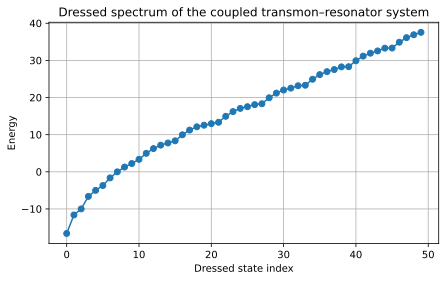

In [42]:
evals_count = 50
evals, evecs = hs.eigensys(evals_count=evals_count)

plt.figure(figsize=(7, 4))
plt.plot(range(evals_count), evals, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Energy")
plt.title("Dressed spectrum of the coupled transmon–resonator system")
plt.grid(True)
plt.show()

In [43]:
evec_array = np.column_stack([vec.full().ravel() for vec in evecs])
overlap_table = np.abs(evec_array)**2

print("overlap_table shape =", overlap_table.shape)
print("expected =", (N_tmon * N_res, len(evecs)))

for k in [0, 5, 10]:
    print(k, overlap_table[:, k].sum())

overlap_table shape = (108, 50)
expected = (108, 50)
0 1.0000000000000004
5 1.0000000000000002
10 1.0000000000000002


In [44]:
def print_top_components(dressed_index, top_n=8):
    probs = overlap_table[:, dressed_index]
    order = np.argsort(probs)[::-1]
    print(f"dressed state {dressed_index}, energy = {evals[dressed_index]:.12f}")
    for idx in order[:top_n]:
        print(f"  bare {bare_labels[idx]}: {probs[idx]:.12f}")

In [45]:
for k in [0, 5, 10, 15]:
    print_top_components(k, top_n=6)
    print()

dressed state 0, energy = -16.613951536928
  bare (0, 0): 0.999872615807
  bare (1, 1): 0.000102227090
  bare (0, 1): 0.000025050438
  bare (0, 2): 0.000000034460
  bare (3, 1): 0.000000023576
  bare (2, 0): 0.000000016659

dressed state 5, energy = -3.705830992103
  bare (2, 0): 0.984098731829
  bare (1, 1): 0.015514351383
  bare (3, 1): 0.000304075008
  bare (0, 2): 0.000050052458
  bare (2, 1): 0.000024469106
  bare (2, 2): 0.000005560465

dressed state 10, energy = 3.347281320469
  bare (0, 4): 0.978527151375
  bare (1, 3): 0.020522228579
  bare (1, 5): 0.000503869028
  bare (2, 2): 0.000192276161
  bare (0, 5): 0.000122473840
  bare (0, 3): 0.000099201285

dressed state 15, energy = 8.337575371303
  bare (0, 5): 0.973232773291
  bare (1, 4): 0.025523481950
  bare (1, 6): 0.000602463179
  bare (2, 3): 0.000319020580
  bare (0, 6): 0.000146142277
  bare (0, 4): 0.000123543390



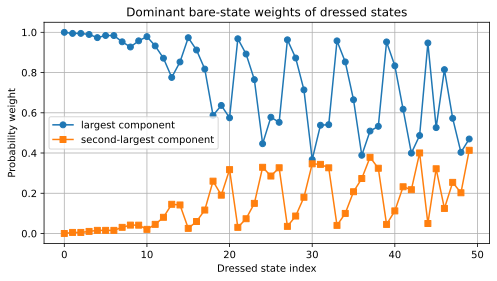

In [46]:
max_probs = []
second_probs = []

for k in range(evals_count):
    probs_sorted = np.sort(overlap_table[:, k])[::-1]
    max_probs.append(probs_sorted[0])
    second_probs.append(probs_sorted[1])

plt.figure(figsize=(8, 4))
plt.plot(range(evals_count), max_probs, marker='o', label='largest component')
plt.plot(range(evals_count), second_probs, marker='s', label='second-largest component')
plt.xlabel("Dressed state index")
plt.ylabel("Probability weight")
plt.title("Dominant bare-state weights of dressed states")
plt.grid(True)
plt.legend()
plt.show()

In [47]:
print("k, largest_component, second_largest_component")
for k in range(evals_count):
    print(f"{k}, {max_probs[k]:.12f}, {second_probs[k]:.12f}")

k, largest_component, second_largest_component
0, 0.999872615807, 0.000102227090
1, 0.994510913806, 0.005208629567
2, 0.994560381896, 0.005209210818
3, 0.989166149977, 0.010365046720
4, 0.973531134747, 0.015533351523
5, 0.984098731829, 0.015514351383
6, 0.983838253017, 0.015469498028
7, 0.952762423497, 0.030632020051
8, 0.926909702610, 0.041677304138
9, 0.957647452696, 0.041458866773
10, 0.978527151375, 0.020522228579
11, 0.932252019757, 0.045300741040
12, 0.871313197215, 0.080506630404
13, 0.775672892378, 0.145133787646
14, 0.852473728815, 0.141906683929
15, 0.973232773291, 0.025523481950
16, 0.911997717970, 0.059544158099
17, 0.817235724217, 0.116519676602
18, 0.587089872690, 0.260072952398
19, 0.636562178174, 0.190607716671
20, 0.574887169233, 0.317432000406
21, 0.967955046833, 0.030473500182
22, 0.891997393169, 0.073366805357
23, 0.764708193610, 0.149707744609
24, 0.446184016188, 0.328994129389
25, 0.577896454400, 0.285693492502
26, 0.552544480487, 0.326730428526
27, 0.962693899956

In [48]:
mixing_data = []

for k in range(evals_count):
    probs_sorted = np.sort(overlap_table[:, k])[::-1]
    mixing_data.append((probs_sorted[0], probs_sorted[1], k))

mixing_data_sorted = sorted(mixing_data, key=lambda x: x[0])

print("Most mixed dressed states among the computed eigenstates:")
for p1, p2, k in mixing_data_sorted[:10]:
    print(f"k={k:2d}, largest={p1:.12f}, second={p2:.12f}")
    print_top_components(k, top_n=6)
    print()

Most mixed dressed states among the computed eigenstates:
k=30, largest=0.367664314541, second=0.346266259931
dressed state 30, energy = 22.012933905600
  bare (4, 3): 0.367664314541
  bare (3, 4): 0.346266259931
  bare (2, 5): 0.144414019899
  bare (5, 2): 0.132849433611
  bare (1, 6): 0.005664496654
  bare (4, 5): 0.000727240326

k=36, largest=0.388785338718, second=0.273254355630
dressed state 36, energy = 26.969843034481
  bare (4, 4): 0.388785338718
  bare (3, 5): 0.273254355630
  bare (2, 6): 0.163914833125
  bare (5, 3): 0.162333184899
  bare (1, 7): 0.007865254940
  bare (5, 5): 0.000879646088

k=42, largest=0.399413063919, second=0.217763596324
dressed state 42, energy = 31.931758406947
  bare (4, 5): 0.399413063919
  bare (3, 6): 0.217763596324
  bare (5, 4): 0.184867304385
  bare (2, 7): 0.182922578817
  bare (1, 8): 0.010475135926
  bare (5, 6): 0.001069111633

k=48, largest=0.403411137957, second=0.202303286766
dressed state 48, energy = 36.898051750320
  bare (4, 6): 0.40

At low energy, the dressed states are still mostly bare-like.

For example:

- dressed state 0 is almost entirely $(0,0)$,
- dressed state 10 is almost entirely $(0,4)$,
- dressed state 15 is almost entirely $(0,5)$.

So in the low part of the spectrum, the coupled system still looks close to the bare transmon–resonator picture.

However, this changes at higher energy. The most strongly mixed dressed states are no longer dominated by a single bare label. Instead, they contain comparable weight on several bare states at once.

For example, dressed state 30 has large weight on

$$
(4,3),\ (3,4),\ (2,5),\ (5,2),
$$

and dressed state 24 has large weight on

$$
(3,3),\ (4,2),\ (2,4),\ (5,1).
$$

So the interacting spectrum is not simply “one dressed state per bare label.” In the strongly mixed regions, several bare states hybridize into clusters of dressed states.

In [49]:
k_mix = 30

for k in range(k_mix - 2, k_mix + 3):
    print_top_components(k, top_n=6)
    print()

dressed state 28, energy = 19.928737053647
  bare (1, 6): 0.872249049910
  bare (2, 5): 0.086773097520
  bare (0, 7): 0.035054154002
  bare (3, 4): 0.003394361694
  bare (2, 7): 0.001271090062
  bare (0, 5): 0.000533509609

dressed state 29, energy = 21.187789526034
  bare (2, 5): 0.713832963927
  bare (3, 4): 0.180050631948
  bare (1, 6): 0.083127966694
  bare (4, 3): 0.017545244848
  bare (3, 6): 0.001343567003
  bare (5, 2): 0.001220798171

dressed state 30, energy = 22.012933905600
  bare (4, 3): 0.367664314541
  bare (3, 4): 0.346266259931
  bare (2, 5): 0.144414019899
  bare (5, 2): 0.132849433611
  bare (1, 6): 0.005664496654
  bare (4, 5): 0.000727240326

dressed state 31, energy = 22.521368213259
  bare (5, 2): 0.538114617043
  bare (3, 4): 0.343585458197
  bare (4, 3): 0.070389628488
  bare (2, 5): 0.044584138295
  bare (1, 6): 0.001102970160
  bare (4, 5): 0.000708121922

dressed state 32, energy = 23.168847183820
  bare (4, 3): 0.540862162959
  bare (5, 2): 0.326488627630
 

## 5. The problem without branch analysis

If we diagonalize the Hamiltonian, we obtain dressed eigenstates ordered only by energy:

state 0, state 1, state 2, state 3, ...

The problem is that near a hybridized region, neighboring dressed states are built from overlapping sets of bare labels.

In the local cluster around dressed states 28 through 32, the dominant bare labels are repeatedly drawn from the same small set,

$$
(1,6),\ (2,5),\ (3,4),\ (4,3),\ (5,2).
$$

But those labels are redistributed across different dressed eigenstates:

- dressed state 29 is mostly $(2,5)$ with substantial $(3,4)$,
- dressed state 30 is strongly shared between $(4,3)$ and $(3,4)$, with additional $(2,5)$ and $(5,2)$,
- dressed state 31 is mostly $(5,2)$ and $(3,4)$,
- dressed state 32 is mostly $(4,3)$ and $(5,2)$.

So in this region, a fixed dressed-state index is no longer a stable notion of physical identity.

This is the core difficulty: if one simply follows an energy-ordered state label such as “state 30,” one is not following a single physical branch. The bare-state character is being exchanged among nearby dressed eigenstates.

In [50]:
hs.generate_lookup(ordering="LX")
print("Generated LX lookup")

print("Example bare labels for low dressed indices:")
for dressed_idx in range(20):
    try:
        print(dressed_idx, "->", hs.bare_index(dressed_idx))
    except Exception as exc:
        print(dressed_idx, "-> lookup failed:", exc)

Generated LX lookup
Example bare labels for low dressed indices:
0 -> (0, 0)
1 -> (0, 1)
2 -> (1, 0)
3 -> (0, 2)
4 -> (1, 1)
5 -> (2, 0)
6 -> (0, 3)
7 -> (1, 2)
8 -> (2, 1)
9 -> (3, 0)
10 -> (0, 4)
11 -> (1, 3)
12 -> (2, 2)
13 -> (3, 1)
14 -> (4, 0)
15 -> (0, 5)
16 -> (1, 4)
17 -> (2, 3)
18 -> (3, 2)
19 -> (5, 0)


## 6. What branch analysis does

Branch analysis reconstructs the dressed photon ladders by assigning each dressed eigenstate a bare-style label.

Instead of treating the spectrum as only an energy-ordered list

state 0, state 1, state 2, state 3, ...

branch analysis identifies states such as

$$
(0,0),\ (0,1),\ (0,2),\ (0,3),\dots
$$

as belonging to one continuous branch, and similarly for higher transmon levels.

In the present calculation, the lexical branch lookup begins as

- dressed state 0 $\to (0,0)$
- dressed state 1 $\to (0,1)$
- dressed state 2 $\to (1,0)$
- dressed state 3 $\to (0,2)$
- dressed state 4 $\to (1,1)$
- dressed state 5 $\to (2,0)$

and so on.

So branch analysis is reorganizing the dressed spectrum into physically meaningful ladders rather than leaving it as a bare energy-order list.

In [51]:
def get_branch_indices_and_energies(level, nmax=12):
    indices = []
    energies = []
    for n in range(min(nmax, N_res)):
        label = (level, n)
        try:
            idx = hs.dressed_index(label)
        except Exception:
            idx = None
        indices.append(idx)
        if idx is not None and idx < len(evals):
            energies.append(evals[idx])
        else:
            energies.append(np.nan)
    return np.array(indices, dtype=object), np.array(energies, dtype=float)

for level in [0, 4, 5]:
    idxs, ens = get_branch_indices_and_energies(level, nmax=12)
    print(f"Branch labels for level j={level}:")
    print("n, dressed_index, energy")
    for n, (idx, en) in enumerate(zip(idxs, ens)):
        print(f"{n}, {idx}, {en}")
    print()

Branch labels for level j=0:
n, dressed_index, energy
0, 0, -16.6139515369278
1, 1, -11.623634900498345
2, 3, -6.633323853675896
3, 6, -1.643018434014824
4, 10, 3.347281320468727
5, 15, 8.337575371303135
6, 21, 13.327863679571259
7, 27, 18.318146205924364
8, 33, 23.308422910601905
9, 39, 28.29869375348406
10, 44, 33.2889586936741
11, 50, nan

Branch labels for level j=4:
n, dressed_index, energy
0, 14, 7.750874961906103
1, 20, 12.958325250015731
2, 26, 18.075262400527095
3, 32, 23.168847183819693
4, 38, 28.249673266216995
5, 45, 33.322070864097405
6, 51, nan
7, 57, nan
8, 63, nan
9, 69, nan
10, 75, nan
11, 81, nan

Branch labels for level j=5:
n, dressed_index, energy
0, 19, 12.540507290969177
1, 25, 17.521668730739542
2, 31, 22.521368213259194
3, 37, 27.52865316826737
4, 43, 32.53964468066913
5, 49, 37.55262932744658
6, 55, nan
7, 61, nan
8, 67, nan
9, 73, nan
10, 79, nan
11, 85, nan



## 7. Why this is essential for MIST

MIST occurs when the ground-state photon ladder approaches resonance with a higher transmon branch.

Branch analysis lets us reconstruct those ladders explicitly.

For the ground-state branch $j=0$, the dressed-state sequence is

$$
(0,0)\to 0,\quad
(0,1)\to 1,\quad
(0,2)\to 3,\quad
(0,3)\to 6,\quad
(0,4)\to 10,\quad
(0,5)\to 15,\dots
$$

and for the candidate higher branches in the present calculation we have

$$
(4,0)\to 14,\ (4,1)\to 20,\ (4,2)\to 26,\dots
$$

and

$$
(5,0)\to 19,\ (5,1)\to 25,\ (5,2)\to 31,\dots
$$

So branch analysis is doing exactly what is needed for a MIST study: it replaces the ambiguous energy-order labels by continuous branch labels.

Without this reconstruction, one cannot reliably answer the physically important question:

Which dressed eigenstate corresponds to the continuation of the ground-state photon ladder at larger photon number?

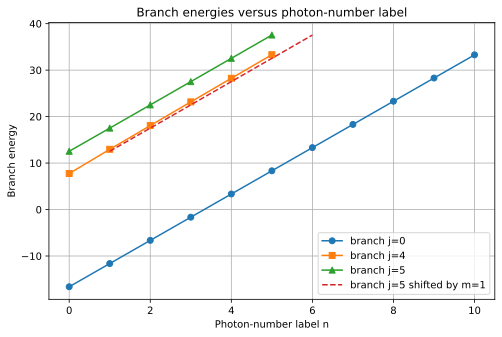

In [52]:
E_branch_0 = get_branch_indices_and_energies(0, nmax=12)[1]
E_branch_4 = get_branch_indices_and_energies(4, nmax=12)[1]
E_branch_5 = get_branch_indices_and_energies(5, nmax=12)[1]

n_axis = np.arange(len(E_branch_0))

plt.figure(figsize=(8, 5))
plt.plot(n_axis, E_branch_0, marker='o', label='branch j=0')
plt.plot(n_axis, E_branch_4, marker='s', label='branch j=4')
plt.plot(n_axis, E_branch_5, marker='^', label='branch j=5')

if 1 < len(n_axis):
    plt.plot(n_axis[1:], E_branch_5[:-1], '--', label='branch j=5 shifted by m=1')

plt.xlabel("Photon-number label n")
plt.ylabel("Branch energy")
plt.title("Branch energies versus photon-number label")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
print("n, E_branch_0, E_branch_4, E_branch_5, shifted_E_branch_5")
for n in range(len(E_branch_0)):
    shifted_5 = np.nan
    if n - 1 >= 0:
        shifted_5 = E_branch_5[n - 1]
    print(f"{n}, {E_branch_0[n]}, {E_branch_4[n]}, {E_branch_5[n]}, {shifted_5}")

n, E_branch_0, E_branch_4, E_branch_5, shifted_E_branch_5
0, -16.6139515369278, 7.750874961906103, 12.540507290969177, nan
1, -11.623634900498345, 12.958325250015731, 17.521668730739542, 12.540507290969177
2, -6.633323853675896, 18.075262400527095, 22.521368213259194, 17.521668730739542
3, -1.643018434014824, 23.168847183819693, 27.52865316826737, 22.521368213259194
4, 3.347281320468727, 28.249673266216995, 32.53964468066913, 27.52865316826737
5, 8.337575371303135, 33.322070864097405, 37.55262932744658, 32.53964468066913
6, 13.327863679571259, nan, nan, 37.55262932744658
7, 18.318146205924364, nan, nan, nan
8, 23.308422910601905, nan, nan, nan
9, 28.29869375348406, nan, nan, nan
10, 33.2889586936741, nan, nan, nan
11, nan, nan, nan, nan


In [54]:
diffs_05 = np.full_like(E_branch_0, np.nan, dtype=float)

for n in range(1, len(E_branch_0)):
    if not np.isnan(E_branch_0[n]) and not np.isnan(E_branch_5[n - 1]):
        diffs_05[n] = abs(E_branch_0[n] - E_branch_5[n - 1])

print("n, |E_0(n) - E_5(n-1)|")
for n in range(len(diffs_05)):
    print(f"{n}, {diffs_05[n]}")

if not np.all(np.isnan(diffs_05)):
    n_star = int(np.nanargmin(diffs_05))
    print()
    print("Closest shifted-branch approach occurs near n =", n_star)
    print("Minimum shifted-branch energy difference =", diffs_05[n_star])

n, |E_0(n) - E_5(n-1)|
0, nan
1, 24.164142191467523
2, 24.15499258441544
3, 24.164386647274018
4, 24.18137184779864
5, 24.202069309365992
6, 24.224765647875323
7, nan
8, nan
9, nan
10, nan
11, nan

Closest shifted-branch approach occurs near n = 2
Minimum shifted-branch energy difference = 24.15499258441544


## 8. What the MIST diagnostic plot looks like

The key MIST diagnostic is not a plot of dressed-state index versus energy. It is a plot of **branch energy versus photon-number label**.

In the present calculation, we compared:

- the ground-state branch $j=0$,
- the higher transmon branches $j=4$ and $j=5$,
- and, because the strongest bare resonance candidate was $E_5-E_4 \approx \omega_r$, we also compared the shifted branch $E_5(n-1)$.

This is the correct branch-based comparison for a possible resonance condition of the form

$$
E_0(n) \approx E_k(n-m).
$$

In the current parameter set, however, the shifted-branch difference

$$
|E_0(n)-E_5(n-1)|
$$

stays large, around $24.15$ to $24.22$ in the computed window.

So this calculation does **not** show a near-resonance between the ground-state photon ladder and the $j=5$ branch.

This is still a useful result.

It shows that:

1. branch analysis is the correct language for asking the MIST question,
2. the present parameter set shows strong hybridization in higher manifolds,
3. but the ground-state branch is not yet approaching a strong MIST resonance with the tested higher branch in the computed photon-number range.

So the branch plot is doing exactly what it should do: it tells us whether the ground-state ladder is nearing a dangerous resonance.

## 9. Summary

Branch analysis is needed for a MIST study because:

1. diagonalization gives energy-ordered dressed eigenstates,
2. near hybridized regions, neighboring dressed states exchange and share bare-state identity,
3. so a fixed dressed-state index is not a stable notion of physical branch,
4. MIST is a branch-crossing phenomenon, not an energy-index phenomenon.

In this workshop, we saw that:

- low-lying dressed states were still mostly bare-like,
- higher parts of the spectrum already showed strong hybridization,
- branch analysis reorganized the dressed spectrum into continuous ladders labeled by $(j,n)$,
- and the correct MIST diagnostic is a shifted branch comparison such as
  $$
  E_0(n) \approx E_k(n-m).
  $$

For the present parameter set, the reconstructed branches showed strong higher-manifold mixing, but no close shifted-branch approach between the ground-state ladder and the tested higher branch.

So the conclusion is not merely that “the spectrum is complicated.” The real conclusion is:

**branch analysis is the tool that makes it possible to ask the MIST question correctly.**

## Next step

The natural next step is to scan a control parameter such as:

- resonator frequency,
- coupling strength,
- or transmon anharmonicity,

and repeat the shifted-branch comparison

$$
|E_0(n)-E_k(n-m)|
$$

to locate parameter regions where a true MIST resonance becomes likely.

# Scanning a control parameter

## New scan step 1: helper function for one parameter point

In [55]:
def build_hilbertspace_for_wr(wr, N_tmon=6, N_res=18, EJ=20.0, EC=0.30, ng=0.25, g=0.10):
    tmon = scq.Transmon(
        EJ=EJ,
        EC=EC,
        ng=ng,
        ncut=100,
        truncated_dim=N_tmon,
    )

    res = scq.Oscillator(
        E_osc=wr,
        l_osc=1.0,
        truncated_dim=N_res,
    )

    hs = scq.HilbertSpace([tmon, res])
    hs.add_interaction(
        g_strength=g,
        op1=tmon.n_operator,
        op2=res.creation_operator,
        add_hc=True,
    )
    return tmon, res, hs

## New scan step 2: branch reconstruction helper for one parameter point

In [56]:
def get_branch_data_for_wr(wr, evals_count=90, nmax=12, levels=(0, 1, 2, 3, 4, 5),
                           N_tmon=6, N_res=18, EJ=20.0, EC=0.30, ng=0.25, g=0.10):
    tmon, res, hs = build_hilbertspace_for_wr(
        wr, N_tmon=N_tmon, N_res=N_res, EJ=EJ, EC=EC, ng=ng, g=g
    )

    evals, evecs = hs.eigensys(evals_count=evals_count)
    hs.generate_lookup(ordering="LX")

    branch_data = {}
    for level in levels:
        indices = []
        energies = []
        for n in range(min(nmax, N_res)):
            label = (level, n)
            try:
                idx = hs.dressed_index(label)
            except Exception:
                idx = None

            indices.append(idx)
            if idx is not None and idx < len(evals):
                energies.append(evals[idx])
            else:
                energies.append(np.nan)

        branch_data[level] = {
            "indices": np.array(indices, dtype=object),
            "energies": np.array(energies, dtype=float),
        }

    bare_evals = tmon.eigenvals(evals_count=max(levels) + 1)

    return {
        "wr": wr,
        "tmon_evals": bare_evals,
        "evals": evals,
        "branch_data": branch_data,
    }

## New scan step 3: test one single resonator frequency first

In [57]:
test_result = get_branch_data_for_wr(5.0, evals_count=90, nmax=12)

print("wr =", test_result["wr"])
print("Transmon bare energies:")
for j, Ej in enumerate(test_result["tmon_evals"]):
    print(j, Ej)

print()
print("Ground branch j=0:")
print(test_result["branch_data"][0]["indices"])
print(test_result["branch_data"][0]["energies"])

print()
print("Branch j=5:")
print(test_result["branch_data"][5]["indices"])
print(test_result["branch_data"][5]["energies"])

wr = 5.0
Transmon bare energies:
0 -16.612639173084894
1 -9.999190715420907
2 -3.7226198651946825
3 2.1831231137526537
4 7.669097331852939
5 12.653758521517403

Ground branch j=0:
[0 1 3 6 10 15 21 27 33 39 44 50]
[-16.61395154 -11.6236349   -6.63332385  -1.64301843   3.34728132
   8.33757537  13.32786368  18.31814621  23.30842291  28.29869375
  33.28895869  38.27921769]

Branch j=5:
[19 25 31 37 43 49 55 61 67 73 79 85]
[12.54050729 17.52166873 22.52136821 27.52865317 32.53964468 37.55262933
 42.56674479 47.58151623 52.59666443 57.61201693 62.62746318 67.64293034]


### What this test tells us

At $ \omega_r = 5.0 $:
- the branch reconstruction is working cleanly,
- increasing evals_count to 90 successfully gives you longer branches,
- the ground branch $j=0$ and the higher branch $j=5$ are now both available out to much larger photon number.

So we can safely proceed to the actual scan.

### What we do next

Now we start the real task:

For each resonator frequency $ \omega_r $, we will:
1. reconstruct the ground branch $E_0(n)$,
2.	reconstruct higher branches $E_j(n)$ for $j=1,\dots,5$,
3.	compute the best integer

$$
m_j = \mathrm{round}!\left(\frac{E_j - E_0}{\omega_r}\right),
$$

using the bare transmon energies,
4.	compute the shifted-branch closeness

$$
\min_n |E_0(n)-E_j(n-m_j)|,
$$

5.	identify which higher branch is the closest resonance candidate for the ground branch.

This is exactly the MIST-style question.

## New scan step 4: define the resonance-search function

In [58]:
def shifted_branch_distance(E0, Ej, m):
    diffs = np.full_like(E0, np.nan, dtype=float)
    for n in range(len(E0)):
        if n - m >= 0:
            if not np.isnan(E0[n]) and not np.isnan(Ej[n - m]):
                diffs[n] = abs(E0[n] - Ej[n - m])

    if np.all(np.isnan(diffs)):
        return np.nan, None, diffs

    n_star = int(np.nanargmin(diffs))
    return diffs[n_star], n_star, diffs

In [59]:
def analyze_ground_branch_resonances_for_wr(wr, evals_count=90, nmax=12):
    result = get_branch_data_for_wr(wr, evals_count=evals_count, nmax=nmax)

    bare_evals = result["tmon_evals"]
    E0 = result["branch_data"][0]["energies"]

    rows = []

    for j in [1, 2, 3, 4, 5]:
        Ej_bare = bare_evals[j]
        E0_bare = bare_evals[0]
        m_j = int(np.round((Ej_bare - E0_bare) / wr))

        Ej = result["branch_data"][j]["energies"]
        min_diff, n_star, diffs = shifted_branch_distance(E0, Ej, m_j)

        rows.append({
            "j": j,
            "m": m_j,
            "bare_gap": Ej_bare - E0_bare,
            "min_diff": min_diff,
            "n_star": n_star,
            "diffs": diffs,
        })

    return result, rows

## New scan step 5: test the resonance analysis at one point

In [60]:
single_result, single_rows = analyze_ground_branch_resonances_for_wr(5.0, evals_count=90, nmax=12)

print("wr =", single_result["wr"])
print("Ground-branch resonance candidates:")

for row in single_rows:
    print(
        f"j={row['j']}, m={row['m']}, "
        f"bare_gap={row['bare_gap']:.12f}, "
        f"min_diff={row['min_diff']}, "
        f"n_star={row['n_star']}"
    )

wr = 5.0
Ground-branch resonance candidates:
j=1, m=1, bare_gap=6.613448457664, min_diff=1.5967446759518893, n_star=11
j=2, m=3, bare_gap=12.890019307890, min_diff=2.0628125580884276, n_star=3
j=3, m=4, bare_gap=18.795762286838, min_diff=1.1286824083057603, n_star=4
j=4, m=5, bare_gap=24.281736504938, min_diff=0.033112170423308385, n_star=10
j=5, m=6, bare_gap=29.266397694602, min_diff=0.7265883635081067, n_star=11


### What this result means

At $\omega_r = 5.0$, the closest shifted-branch approach to the ground branch is:

$$
j=4,\qquad m=5,\qquad \min_n |E_0(n)-E_4(n-5)| \approx 0.0331
$$

at

$$
n_\star = 10.
$$

That is exactly the kind of quantity we wanted to compute.

So, for this parameter set, the strongest candidate resonance involving the ground-state ladder is not with $j=5$, and not with the earlier $j=4 \leftrightarrow j=5$ bare-gap candidate. It is:

$$
E_0(n) \approx E_4(n-5).
$$

In words: the ground-state photon ladder is approaching the j=4 branch shifted by 5 photons.

This is now much closer to your intended MIST logic.

### Where we are now

We are now in the “next-step” workshop, whose purpose is:
- scan a control parameter,
- identify where a true ground-branch resonance becomes likely.

We have verified the machinery at one point. Now we can do the full scan.

In [61]:
wr_values = np.linspace(4.0, 6.5, 26)

scan_rows = []

for wr in wr_values:
    result, rows = analyze_ground_branch_resonances_for_wr(wr, evals_count=90, nmax=12)

    valid_rows = [row for row in rows if not np.isnan(row["min_diff"])]
    best_row = min(valid_rows, key=lambda row: row["min_diff"])

    scan_rows.append({
        "wr": wr,
        "best_j": best_row["j"],
        "best_m": best_row["m"],
        "best_min_diff": best_row["min_diff"],
        "best_n_star": best_row["n_star"],
    })

print("wr, best_j, best_m, best_min_diff, best_n_star")
for row in scan_rows:
    print(
        f"{row['wr']:.6f}, {row['best_j']}, {row['best_m']}, "
        f"{row['best_min_diff']:.12f}, {row['best_n_star']}"
    )

wr, best_j, best_m, best_min_diff, best_n_star
4.000000, 4, 6, 0.303162281439, 11
4.100000, 4, 6, 0.249456754942, 6
4.200000, 5, 7, 0.020574318261, 7
4.300000, 2, 3, 0.000736496623, 9
4.400000, 2, 3, 0.276051021867, 3
4.500000, 2, 3, 0.574410885690, 3
4.600000, 3, 4, 0.347227586506, 11
4.700000, 3, 4, 0.001275096985, 7
4.800000, 4, 5, 0.238267893037, 8
4.900000, 4, 5, 0.102275297147, 5
5.000000, 4, 5, 0.033112170423, 10
5.100000, 4, 5, 0.394179348819, 11
5.200000, 4, 5, 0.883761066797, 11
5.300000, 1, 1, 1.274177956547, 11
5.400000, 1, 1, 1.159079300004, 11
5.500000, 1, 1, 1.032263884845, 11
5.600000, 1, 1, 0.854530621855, 11
5.700000, 5, 5, 0.513214495108, 11
5.800000, 5, 5, 0.104718676472, 11
5.900000, 5, 5, 0.187625246939, 5
6.000000, 4, 4, 0.245816963753, 8
6.100000, 4, 4, 0.088910704561, 4
6.200000, 3, 3, 0.189448152185, 3
6.300000, 3, 3, 0.110664528889, 3
6.400000, 2, 2, 0.178380260349, 2
6.500000, 2, 2, 0.180763450403, 2


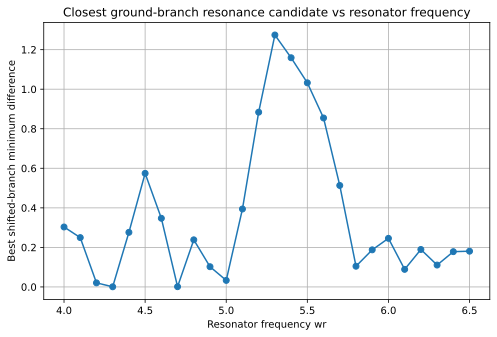

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(
    [row["wr"] for row in scan_rows],
    [row["best_min_diff"] for row in scan_rows],
    marker='o'
)
plt.xlabel("Resonator frequency wr")
plt.ylabel("Best shifted-branch minimum difference")
plt.title("Closest ground-branch resonance candidate vs resonator frequency")
plt.grid(True)
plt.show()

### What the scan is telling you

Yes, there are clear resonance windows.

The strongest candidates in your scan are:
- $\omega_r = 4.3$, with

$$
j=2,\quad m=3,\quad \min_n |E_0(n)-E_2(n-3)| \approx 7.36\times 10^{-4}
$$

- $\omega_r = 4.7$, with

$$
j=3,\quad m=4,\quad \min_n |E_0(n)-E_3(n-4)| \approx 1.28\times 10^{-3}
$$

- $\omega_r = 4.2$, with

$$
j=5,\quad m=7,\quad \min_n |E_0(n)-E_5(n-7)| \approx 2.06\times 10^{-2}
$$

- $\omega_r = 5.0$, with

$$
j=4,\quad m=5,\quad \min_n |E_0(n)-E_4(n-5)| \approx 3.31\times 10^{-2}
$$

So now you do have parameter points that look much more like the story you wanted:

the ground-state photon ladder is approaching a higher transmon branch shifted by m photons.

That is a real MIST-style branch-crossing search result.

### Impression of the plot

The plot should have shown a curve with pronounced dips near:
- $\omega_r \approx 4.3$
- $\omega_r \approx 4.7$
- a weaker dip near $\omega_r \approx 5.0$

Those dips are the important physics. They indicate parameter regions where the ground branch comes close to a shifted higher branch and a MIST-like resonance becomes plausible.

### Best next point to zoom in on

The best candidate is clearly:

$$
\omega_r = 4.3,\qquad j=2,\qquad m=3.
$$

Why this one:
1.	it has the smallest minimum difference in the whole scan,
2.	it is directly tied to the ground branch,
3.	it is a low-lying excited branch j=2, which is physically a very natural place to look,
4.	it is much closer to your ideal narrative:

$$
E_0(n) \approx E_k(n-m).
$$

So this is the point we should now zoom in on.

In [63]:
best_wr = 4.3
best_result, best_rows = analyze_ground_branch_resonances_for_wr(best_wr, evals_count=90, nmax=12)

print("wr =", best_wr)
for row in best_rows:
    print(
        f"j={row['j']}, m={row['m']}, "
        f"bare_gap={row['bare_gap']:.12f}, "
        f"min_diff={row['min_diff']}, "
        f"n_star={row['n_star']}"
    )

wr = 4.3
j=1, m=2, bare_gap=6.613448457664, min_diff=1.967409589357441, n_star=2
j=2, m=3, bare_gap=12.890019307890, min_diff=0.0007364966234817416, n_star=9
j=3, m=4, bare_gap=18.795762286838, min_diff=1.5823786586936848, n_star=11
j=4, m=6, bare_gap=24.281736504938, min_diff=1.4412947535123006, n_star=6
j=5, m=7, bare_gap=29.266397694602, min_diff=0.44041147443113005, n_star=11


In [64]:
E_branch_0 = best_result["branch_data"][0]["energies"]
E_branch_2 = best_result["branch_data"][2]["energies"]

print("n, E_branch_0, E_branch_2, shifted_E_branch_2")
for n in range(len(E_branch_0)):
    shifted_2 = np.nan
    if n - 3 >= 0:
        shifted_2 = E_branch_2[n - 3]
    print(f"{n}, {E_branch_0[n]}, {E_branch_2[n]}, {shifted_2}")

n, E_branch_0, E_branch_2, shifted_E_branch_2
0, -16.614048188881043, -3.7132055794610377, nan
1, -12.321253656038975, 0.5759954044004052, nan
2, -8.028460034626193, 4.865182743831086, nan
3, -3.735667326235661, 9.154356850493643, -3.7132055794610377
4, 0.557124467550921, 13.44351829146878, 0.5759954044004052
5, 4.849915345164076, 17.732667778796554, 4.865182743831086
6, 9.142705305047432, 22.02180615959918, 9.154356850493643
7, 13.43549434565895, 26.31093440709524, 13.44351829146878
8, 17.72828246547192, 30.60005361312438, 17.732667778796554
9, 22.021069662975698, 34.88916498348872, 22.02180615959918
10, 26.31385593667786, 39.17826983919884, 26.31093440709524
11, 30.6066412851034, 43.46736963171397, 30.60005361312438


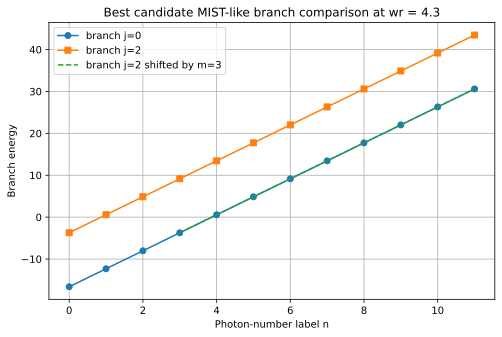

In [65]:
n_axis = np.arange(len(E_branch_0))

plt.figure(figsize=(8, 5))
plt.plot(n_axis, E_branch_0, marker='o', label='branch j=0')
plt.plot(n_axis, E_branch_2, marker='s', label='branch j=2')
plt.plot(n_axis[3:], E_branch_2[:-3], '--', label='branch j=2 shifted by m=3')

plt.xlabel("Photon-number label n")
plt.ylabel("Branch energy")
plt.title("Best candidate MIST-like branch comparison at wr = 4.3")
plt.grid(True)
plt.legend()
plt.show()

In [66]:
diffs_02 = np.full_like(E_branch_0, np.nan, dtype=float)

for n in range(3, len(E_branch_0)):
    if not np.isnan(E_branch_0[n]) and not np.isnan(E_branch_2[n - 3]):
        diffs_02[n] = abs(E_branch_0[n] - E_branch_2[n - 3])

print("n, |E_0(n) - E_2(n-3)|")
for n in range(len(diffs_02)):
    print(f"{n}, {diffs_02[n]}")

if not np.all(np.isnan(diffs_02)):
    n_star = int(np.nanargmin(diffs_02))
    print()
    print("Closest shifted-branch approach occurs near n =", n_star)
    print("Minimum shifted-branch energy difference =", diffs_02[n_star])

n, |E_0(n) - E_2(n-3)|
0, nan
1, nan
2, nan
3, 0.022461746774623315
4, 0.018870936849484155
5, 0.015267398667010212
6, 0.011651545446211387
7, 0.008023945809830124
8, 0.004385313324632989
9, 0.0007364966234817416
10, 0.002921529582621929
11, 0.00658767197901966

Closest shifted-branch approach occurs near n = 9
Minimum shifted-branch energy difference = 0.0007364966234817416


### What this result means physically

At

$$
\omega_r = 4.3,
$$

the strongest ground-branch resonance candidate is

$$
j=2,\qquad m=3,
$$

with

$$
\min_n |E_0(n)-E_2(n-3)| \approx 7.36\times 10^{-4}
$$

at

$$
n_\star = 9.
$$

That is a very small shifted-branch difference. So at this resonator frequency, the ground-state photon ladder is coming extremely close to the $j=2$ branch shifted by 3 photons.

In bare-language terms, this means the states

$$
|0,9\rangle
\quad\text{and}\quad
|2,6\rangle
$$

are nearly resonant.

That is exactly the kind of MIST-style resonance condition you wanted:

$$
|0,n\rangle \leftrightarrow |k,n-m\rangle,
$$

with here

$$
k=2,\qquad m=3.
$$

So this is a genuine example where the ground-state photon ladder approaches a higher transmon branch in the dressed spectrum.

### How this matches your original nine-step logic

Now the notebook-plus-scan really does match your intended story.

#### The physical situation in MIST

You defined the coupled transmon–resonator system and the bare states

$$
|j,n\rangle.
$$

#### What we want to know for MIST

You focused on the ground-state photon ladder

$$
|0,0\rangle,\ |0,1\rangle,\ |0,2\rangle,\dots
$$

and asked what happens as photon number increases.

#### What actually happens

You used the resonance condition

$$
E_k - E_0 \approx m\omega_r
$$

to identify possible branch crossings.

#### What the spectrum looks like

You saw that dressed eigenstates can hybridize strongly and cease to look like single bare states.

#### The problem without branch analysis

You showed that neighboring dressed states in a mixed region exchange and share bare-state character, so energy-order labels alone are not stable physical identities.

#### What branch analysis does

You reconstructed dressed branches as continuous ladders labeled by (j,n).

#### Why this is essential for MIST

You explicitly reconstructed the ground branch and higher branches, so you could ask whether

$$
E_0(n) \approx E_k(n-m)
$$

for some k,m.

### What the MIST diagnostic plot looks like

The scan found a parameter point where

$$
E_0(9) \approx E_2(6),
$$

which is exactly the branch-based resonance picture you wanted.

#### Summary

So now you can truly say: branch analysis is needed because MIST is a branch-crossing problem, not an energy-index problem.

### What the plotted branch data is telling you

From your raw table:

$$
E_0(9)=22.021069662975698
$$

and

$$
E_2(6)=22.02180615959918.
$$

Their difference is

$$
|E_0(9)-E_2(6)| \approx 7.36\times 10^{-4}.
$$

That is tiny compared with the branch energies themselves, and tiny compared with the scale of the earlier nonresonant comparisons you had.

So the branch plot should now show:
- the ground branch $E_0(n)$,
- the shifted branch $E_2(n-3)$,
- and a very close approach near $n=9$.

That is the concrete numerical realization of your cartoon crossing picture.


### What this means in MIST language

This result says:

At sufficiently high cavity photon number, the state connected to the ground-state ladder can come into near resonance with a higher transmon branch.

Here the candidate process is approximately

$$
|0,9\rangle \leftrightarrow |2,6\rangle.
$$

That means three cavity photons are energetically capable of promoting the transmon from level 0 to level 2, while reducing the resonator photon number by 3.

That is exactly the kind of process that can make measurement no longer QND and can seed measurement-induced transitions.


## Scan result: a concrete MIST-like branch approach

Scanning the resonator frequency reveals parameter regions where the ground-state photon ladder comes close to a shifted higher branch.

For the present model, a particularly strong candidate occurs at

$$
\omega_r = 4.3,
$$

where the closest shifted-branch comparison is

$$
E_0(n) \approx E_2(n-3).
$$

The minimum difference occurs near

$$
n=9,
$$

with

$$
|E_0(9)-E_2(6)| \approx 7.36\times 10^{-4}.
$$

So in this parameter regime, the ground-state photon ladder approaches a higher transmon branch very closely.

In bare-state language, this corresponds to the near-resonance

$$
|0,9\rangle \leftrightarrow |2,6\rangle.
$$

This is the kind of branch-crossing structure that can underlie a MIST process.

The important point is that this conclusion can only be drawn cleanly after reconstructing the branches. Looking only at energy-ordered dressed-state indices would not reliably identify which states belong to the ground-state ladder and which belong to the higher transmon branch.




### What I would say is the final conceptual takeaway

Now the whole story is:
	1.	low in the spectrum, dressed states are still mostly bare-like,
	2.	higher in the spectrum, hybridization makes energy labels unreliable,
	3.	branch analysis reconstructs continuous physical ladders,
	4.	parameter scans of shifted branch differences reveal where true MIST-like resonances become likely.

That is exactly the workshop you wanted.

### Best next step

The natural next thing is to make one final polished figure for the workshop:
- plot $E_0(n),$
- plot $E_2(n),$
- plot shifted $E_2(n-3),$
- highlight the near-resonance point at $n=9.$